In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\TY-Dl-codes\House Price Prediction(6)\data.csv")

# Clean column names (safe practice)
df.columns = df.columns.str.strip()

# Use only first 1000 rows for speed
df = df.head(1000)

print("Shape:", df.shape)
df.head()

Shape: (1000, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "floors",
    "condition",
    "yr_built"
]

X = df[features].values
y = df["price"].values.reshape(-1, 1)

print("Feature Shape:", X.shape)

Feature Shape: (1000, 6)


In [6]:
# Drop rows with missing values
mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y).flatten()
X = X[mask]
y = y[mask]

# Normalize features and target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.3, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (700, 6)
Test Shape: (300, 6)


In [8]:
k = 10
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_train)

centers = kmeans.cluster_centers_

print("RBF Centers (K-Means):")
print(pd.DataFrame(centers))

RBF Centers (K-Means):
          0         1         2         3         4         5
0  0.321918  0.219178  0.122715  0.013699  0.496575  0.760394
1  0.398000  0.275310  0.188552  0.500000  0.532000  0.849123
2  0.325688  0.167668  0.102875  0.006881  0.786697  0.600676
3  0.298469  0.187192  0.108500  0.341837  0.581633  0.187075
4  0.226852  0.214559  0.071956  0.972222  0.500000  0.941845
5  0.207661  0.078977  0.061213  0.012097  0.818548  0.346633
6  0.246429  0.092939  0.065196  0.016667  0.490476  0.439766
7  0.231027  0.231527  0.098214  0.497768  0.535714  0.859101
8  0.680556  0.448276  0.312818  0.750000  0.638889  0.263158
9  0.375000  0.205707  0.137142  0.336207  0.982759  0.293103


In [9]:
def compute_sigma(centers):
    sigmas = []
    for i in range(len(centers)):
        distances = np.linalg.norm(centers - centers[i], axis=1)
        distances = np.sort(distances)
        sigma = np.mean(distances[1:3])  # 2 nearest neighbors
        sigmas.append(sigma)
    return np.array(sigmas)

sigmas = compute_sigma(centers)
print("Sigma Values:", sigmas)

Sigma Values: [0.34665951 0.35197224 0.3171779  0.43038413 0.50617658 0.32104275
 0.34998454 0.33954922 0.6725003  0.42654482]


In [10]:
def gaussian_rbf(x, c, sigma):
    return np.exp(-np.linalg.norm(x - c)**2 / (2 * sigma**2))

In [11]:
def compute_phi(X, centers, sigmas):
    n_samples = X.shape[0]
    k = centers.shape[0]
    phi = np.zeros((n_samples, k))
    
    for i in range(n_samples):
        for j in range(k):
            phi[i, j] = gaussian_rbf(X[i], centers[j], sigmas[j])
    
    return phi

phi_train = compute_phi(X_train, centers, sigmas)
phi_test = compute_phi(X_test, centers, sigmas)

print("Phi Train Shape:", phi_train.shape)

Phi Train Shape: (700, 10)


In [12]:
# Add bias term
phi_train_bias = np.c_[np.ones(phi_train.shape[0]), phi_train]

# Least Squares Solution
W = np.linalg.lstsq(phi_train_bias, y_train, rcond=None)[0]

print("Output Weights Shape:", W.shape)

Output Weights Shape: (11, 1)


In [14]:
# Add bias to test phi
phi_test_bias = np.c_[np.ones(phi_test.shape[0]), phi_test]

# Predictions (scaled)
y_pred_scaled = phi_test_bias @ W

In [ ]:
# Add bias to test phi
phi_test_bias = np.c_[np.ones(phi_test.shape[0]), phi_test]

# Predictions (scaled)
y_pred_scaled = phi_test_bias @ W

In [15]:
# Convert back to original price scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_actual = scaler_y.inverse_transform(y_test)

mse = mean_squared_error(y_actual, y_pred)
mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)

print("MSE:", round(mse, 2))
print("MAE:", round(mae, 2))
print("R² Score:", round(r2, 4))

MSE: 60472895384.94
MAE: 169222.36
R² Score: 0.2655


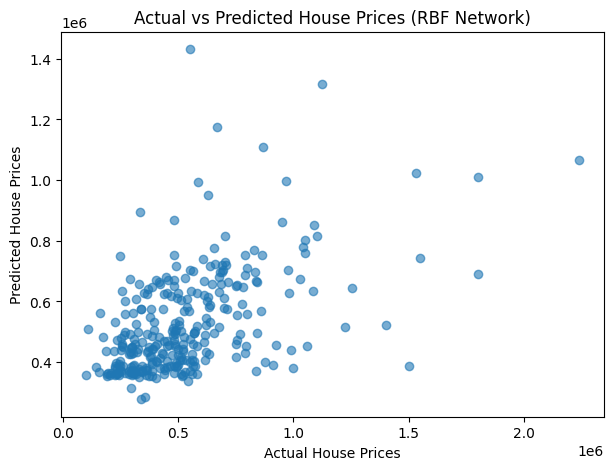

In [16]:
plt.figure(figsize=(7,5))
plt.scatter(y_actual, y_pred, alpha=0.6)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices (RBF Network)")
plt.show()